In [ ]:
import pandas as pd
import numpy as np
from os import getcwd, listdir, path
import matplotlib.pyplot as plt
import sys
import ast
from glob import glob

import fitness.data_generating_process as dgp
import fitness.soga_fitness_SCM as soga_fitness_SCM
import fitness.interventions as interventions

In [ ]:
# Read all pareto_fitness.txt files under results/causal_skills_tests and build aggregated stats
ex_name = 'common_cause_600_2interventions'
program = 'common_cause'
base_dir = path.join('..', 'results', ex_name)
pattern = path.join(base_dir, '**', 'stats.tsv')

# Read ONLY the column best_fitness from all stats.tsv files, change the value tensor(-1000000.) to -1000000.0, and FOR EACH ROW compute mean, std, median and interquartile ranges (25, 75)
# and save the results in a new dataframe with columns: mean, std, median, q25, q75.Do not consider interventions.

files = glob(pattern, recursive=True)
dfs = []
for file in files:
    df = pd.read_csv(file, sep='\t')
    df['best_fitness'] = df['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    dfs.append(df[['best_fitness']])

# for each row, compute mean, std, median, q25 and q75
results = []
for i in range(len(dfs[0])):
    values = [df['best_fitness'].iloc[i] for df in dfs]
    mean = np.mean(values)
    std = np.std(values)
    median = np.median(values)
    q25 = np.percentile(values, 25)
    q75 = np.percentile(values, 75)
    results.append({'mean': mean, 'std': std, 'median': median, 'q25': q25, 'q75': q75})

results_df = pd.DataFrame(results)
print(results_df)


           mean        std      median         q25         q75
0   -333.960385  31.434285 -333.960385 -349.677527 -318.243242
1   -309.543377  55.851293 -309.543377 -337.469023 -281.617730
2   -299.006847  52.737984 -299.006847 -325.375839 -272.637855
3   -261.561918  63.501865 -261.561918 -293.312851 -229.810986
4   -242.699914  82.363870 -242.699914 -283.881849 -201.517979
..          ...        ...         ...         ...         ...
596 -112.156107   6.502855 -112.156107 -115.407535 -108.904680
597 -112.156107   6.502855 -112.156107 -115.407535 -108.904680
598 -112.156107   6.502855 -112.156107 -115.407535 -108.904680
599 -112.156107   6.502855 -112.156107 -115.407535 -108.904680
600 -112.156107   6.502855 -112.156107 -115.407535 -108.904680

[601 rows x 5 columns]


In [ ]:
vars, scm = dgp.get_vars(program)
real_program = dgp.get_real_program(program)
baseline_program = dgp.get_baseline_program(program)
#real_dataset = dgp.generate_interventional_dataset(scm, vars, 1000)

real_dataset_file = f'fitness/datasets/{program}.csv'
real_dataset = np.loadtxt(real_dataset_file, delimiter=',')

likelihood = soga_fitness_SCM.compute_likelihood(real_program, vars, real_dataset)
likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program, vars, real_dataset)

likelihood_intervened = 0
likelihood_base_intervened = 0
print(f'Likelihood of real program: {likelihood}')
print(f'\nLikelihood of baseline program: {likelihood_base}')
interventions_list = dgp.get_intervention_list(program)
for var, value in interventions_list:
    dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
    data_intervened = np.loadtxt(dataset_file, delimiter=',')
    program_intervened = interventions.apply_intervention_to_program(real_program, var, value)
    baseline_program_intervened = interventions.apply_intervention_to_program(baseline_program, var, value)
    interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
    interventional_likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program_intervened, vars, data_intervened)
    likelihood_intervened += interventional_likelihood
    likelihood_base_intervened += interventional_likelihood_base


likelihood = likelihood + 2*likelihood_intervened
likelihood_base = likelihood_base + 2*likelihood_base_intervened
print(f'Total likelihood of real program: {likelihood}')
print(f'Total likelihood of baseline program: {likelihood_base}')


Likelihood of real program: -4.8863618147896215

Likelihood of baseline program: -6.76532461816939
Total likelihood of real program: -64.60879999159664
Total likelihood of baseline program: -108.39307168657065


In [ ]:
# between all the files, find the one with best likelihood and print the corresponding program
best_likelihood = -np.inf
best_program = None
for file in files:
    df = pd.read_csv(file, sep='\t')
    df['best_fitness'] = df['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    max_likelihood = df['best_fitness'].max()
    if max_likelihood > best_likelihood:
        best_likelihood = max_likelihood
        best_program = file 
print(f'Best likelihood: {best_likelihood}')
#print(f'Best program file: {best_program}')

#in the folder where the best stats.tsv file is, print the content of the best.txt file
best_program_file = best_program.replace('stats.tsv', 'best.txt')
with open(best_program_file, 'r') as f:
    best_program_content = f.read()
print(f'Best program content:\n{best_program_content}')

Best likelihood: -105.65325195074084
Best program content:
Generation:
600

Phenotype:
3
V1 = uniform([+9.99e-1, 7.00e-0], 2);
V2 = +V1;
V2 = V2 + gm([6.28e+3, +5.00e+0, 2.49e+0]);
V3 = +7.57e-1 * +5.36e-1;
V3 = V3 + uniform([+3.05e+0, 2.09e+1], 2);

Pre-processed Program
:C = uniform([0.999000, 7.999000], 2);F = C;F = F + gm([1.000000], [5], [2.49]);T = 0.4058;T = T + uniform([3.050000, 23.950000], 2);Genotype:
[260, 194, 426, 307, 474, 269, 44, 349, 269, 159, 443, 145, 235, 237, 330, 50, 137, 452, 292, 216, 26, 58, 114, 489, 80, 125, 16, 8, 396, 82, 58, 92, 343, 299, 142, 205, 230, 340, 250, 48, 332, 42, 204, 379, 180, 488, 498, 468, 137, 488, 337, 13, 484, 117, 455, 327, 147, 309, 417, 121, 476, 235, 53, 236, 319, 433, 125, 308, 291, 280, 223, 170, 45, 494, 80, 279, 432, 460, 49, 266, 441, 329, 139, 268, 347, 316, 177, 356, 248, 408, 201, 331, 320, 276, 56, 365, 382, 126, 429, 14]
Tree:
None
Fitness on 5000 data:
-105.65325195074084

Fitness:
-105.65325195074084


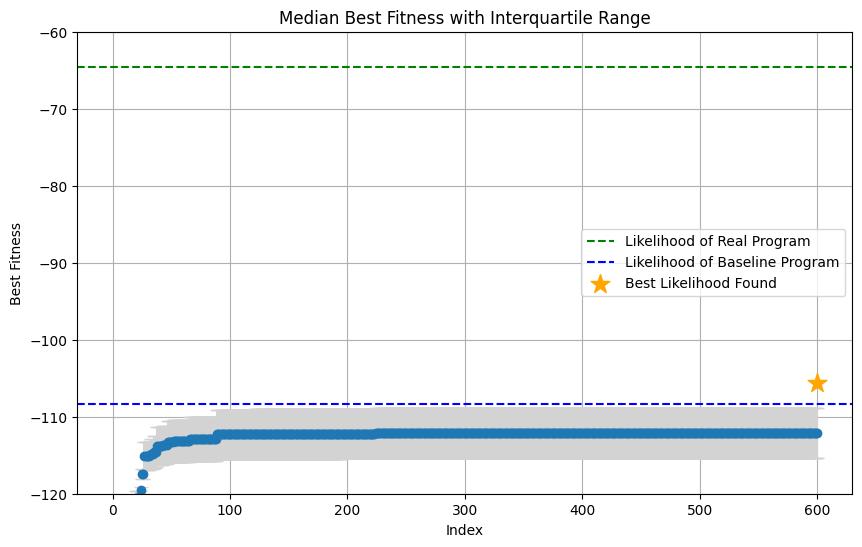

In [ ]:
# Plot results_df median with error bars for q25 and q75
plt.figure(figsize=(10, 6))
plt.errorbar(results_df.index, results_df['median'], yerr=[results_df['median'] - results_df['q25'], results_df['q75'] - results_df['median']], fmt='o', ecolor='lightgray', capsize=5)
plt.title('Median Best Fitness with Interquartile Range')
plt.xlabel('Index')
plt.ylabel('Best Fitness')
plt.ylim(-120, -60)

# Add a horizontal line for the likelihood of the real program and the baseline program
plt.axhline(y=likelihood, color='g', linestyle='--', label='Likelihood of Real Program')
plt.axhline(y=likelihood_base, color='b', linestyle='--', label='Likelihood of Baseline Program')

# Add a point for the best likelihood found in the files with the shape of a star and color orange
plt.scatter(len(results_df)-1, best_likelihood, color='orange', label='Best Likelihood Found', zorder=5, marker='*', s=200)

plt.legend()

plt.grid()
plt.show()